# Atividade: CNNs para Classificação

Neste notebook, iremos preparar nosso próprio dataset e treinar um modelo de classificação de imagens.

## Preparando os dados

Os dados desta atividade serão baixados da internet. Utilizaremos para isso buscadores comuns. Em seguida, dividiremos em treinamento e validação.

In [1]:
!pip install icrawler torch torchvision matplotlib scikit-learn

In [2]:
import os
import shutil
import random
from icrawler.builtin import GoogleImageCrawler, BingImageCrawler

### Adquirindo as Imagens

Utilizaremos o iCrawler para baixar imagens em buscadores através de termos especificados. Defina sua lista de classes.

In [5]:
def download_images(keyword, folder, n_total=100):
    os.makedirs(folder, exist_ok=True)
    downloaded = len(os.listdir(folder))
    remaining = n_total - downloaded

    while downloaded < n_total:
        crawler = BingImageCrawler(storage={'root_dir': folder})
        crawler.crawl(keyword=keyword, max_num=remaining, file_idx_offset=downloaded)
        downloaded = len(os.listdir(folder))
        remaining = n_total - downloaded
        print(f"Downloaded {downloaded}/{n_total}")

    print("Download complete!")

In [9]:
search_terms = {
    "pizza": "pizza food",
    "hamburguer": "burger food",
    "sushi": "sushi platter"
}

base_folder = "data/comidas"

for label, term in search_terms.items():
    print(f"Baixando imagens para: {label}...")
    download_images(term, f"{base_folder}/{label}", n_total=50)

split_train_val(base_folder, train_ratio=0.8)

Baixando imagens para: pizza...
Download complete!
Baixando imagens para: hamburguer...
Download complete!
Baixando imagens para: sushi...
Download complete!
sushi: 40 train, 10 val
pizza: 40 train, 10 val
hamburguer: 40 train, 10 val


### Treinamento e Validação

Dividiremos as imagens baixadas nas pastas `train` e `val`. Defina uma porcentagem.

In [7]:
def split_train_val(root_dir, train_ratio=0.8, seed=42):
    random.seed(seed)

    train_dir = root_dir + "_split/train"
    val_dir = root_dir + "_split/val"

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)

    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [os.path.join(class_path, f) for f in os.listdir(class_path)]
        images = [f for f in images if os.path.isfile(f)]
        random.shuffle(images)

        n_train = int(len(images) * train_ratio)

        train_class_dir = os.path.join(train_dir, class_name)
        val_class_dir = os.path.join(val_dir, class_name)
        os.makedirs(train_class_dir, exist_ok=True)
        os.makedirs(val_class_dir, exist_ok=True)

        for img in images[:n_train]:
            shutil.copy(img, os.path.join(train_class_dir, os.path.basename(img)))
        for img in images[n_train:]:
            shutil.copy(img, os.path.join(val_class_dir, os.path.basename(img)))

        print(f"{class_name}: {n_train} train, {len(images)-n_train} val")

## Dataset

Implemente um Dataset PyTorch que carregue as imagens baixadas com suas respectivas classes. Aplique data augmentation e carregue em batches.

In [10]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Definição de transformações
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((128, 128)),        # Redimensiona todas imagens para tamanho igual
        transforms.RandomHorizontalFlip(),    # Data Augmentation: espelha a imagem aleatoriamente
        transforms.RandomRotation(10),        # Data Augmentation: rotaciona levemente
        transforms.ToTensor(),                # Converte para Tensor PyTorch (0-1)
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Normalização padrão ImageNet
    ]),
    'val': transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = base_folder + "_split" # Pasta criada no passo anterior

# Criando os Datasets
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
                  for x in ['train', 'val']}

# Criando os DataLoaders
dataloaders = {x: DataLoader(image_datasets[x], batch_size=16, shuffle=True, num_workers=2)
               for x in ['train', 'val']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

Classes encontradas: ['hamburguer', 'pizza', 'sushi']
Dispositivo de treino: cpu


## Definição do Modelo

Defina aqui o modelo que será utilizado, sendo implementação própria ou um modelo pré-treinado. Teste diversas arquiteturas diferentes e verifique qual delas tem melhor desempenho em validação.

In [11]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2) # Reduz a dimensão espacial pela metade

        # Camadas fully connected (classificação)
        self.fc1 = nn.Linear(64 * 16 * 16, 512)
        self.fc2 = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # Feature Extraction
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        # Flatten (transforma matriz em vetor)
        x = x.view(-1, 64 * 16 * 16)

        # Classificação
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = SimpleCNN(num_classes=len(class_names)).to(device)
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=3, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


## Treinamento

Defina a função de custo e o otimizador do modelo. Em seguida, implemente o código de treinamento e treine-o. Ao final, exiba as curvas de treinamento e validação para a loss e a acurácia.

Iniciando treinamento...
Epoch 1/10
----------
train Loss: 1.1718 Acc: 0.4083
val Loss: 0.9396 Acc: 0.7333
Epoch 2/10
----------
train Loss: 0.7362 Acc: 0.7583
val Loss: 0.4497 Acc: 0.8333
Epoch 3/10
----------
train Loss: 0.3494 Acc: 0.8417
val Loss: 0.5563 Acc: 0.7333
Epoch 4/10
----------
train Loss: 0.3167 Acc: 0.8917
val Loss: 0.4957 Acc: 0.8333
Epoch 5/10
----------
train Loss: 0.2545 Acc: 0.9000
val Loss: 0.5141 Acc: 0.8667
Epoch 6/10
----------
train Loss: 0.1586 Acc: 0.9417
val Loss: 0.4584 Acc: 0.7667
Epoch 7/10
----------
train Loss: 0.1410 Acc: 0.9417
val Loss: 0.4457 Acc: 0.8333
Epoch 8/10
----------
train Loss: 0.1149 Acc: 0.9333
val Loss: 0.3585 Acc: 0.8000
Epoch 9/10
----------
train Loss: 0.0732 Acc: 0.9750
val Loss: 0.5817 Acc: 0.7000
Epoch 10/10
----------
train Loss: 0.1372 Acc: 0.9250
val Loss: 0.3770 Acc: 0.7667
Melhor Acurácia na Validação: 0.8667


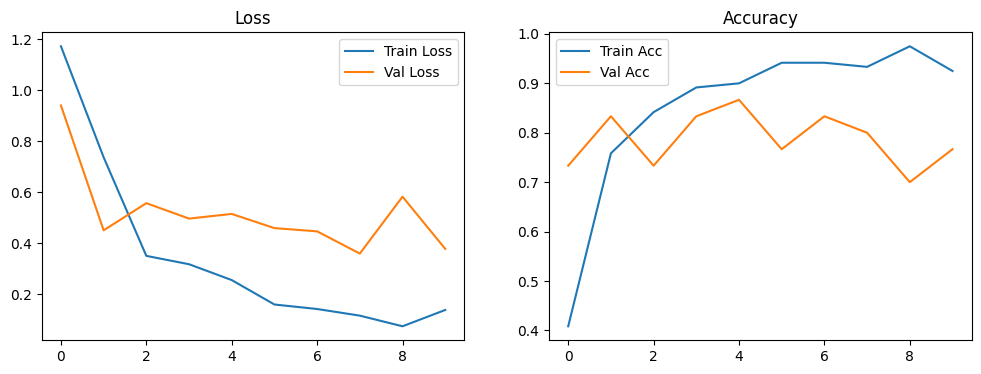

In [12]:
import torch.optim as optim
import matplotlib.pyplot as plt
import copy

# Função de Custo
criterion = nn.CrossEntropyLoss()

# Otimizador
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0

train_loss_history = []
val_loss_history = []
train_acc_history = []
val_acc_history = []

print("Iniciando treinamento...")

for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    print('-' * 10)

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()  # Modo de treino
        else:
            model.eval()   # Modo de avaliação

        running_loss = 0.0
        running_corrects = 0

        # Itera sobre os dados
        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Zera os gradientes
            optimizer.zero_grad()

            # Forward
            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                # Backward + Otimização
                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            # Estatísticas
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]

        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        # Salva histórico
        if phase == 'train':
            train_loss_history.append(epoch_loss)
            train_acc_history.append(epoch_acc.cpu())
        else:
            val_loss_history.append(epoch_loss)
            val_acc_history.append(epoch_acc.cpu())

            # Deep Copy do modelo se for o melhor até agora
            if epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

print(f'Melhor Acurácia na Validação: {best_acc:.4f}')
model.load_state_dict(best_model_wts) # Carrega o melhor modelo

# Plota
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Val Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(train_acc_history, label='Train Acc')
plt.plot(val_acc_history, label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.show()

## Inferência

Calcule algumas métricas como acurácia, matriz de confusão, etc. Em seguida, teste o modelo em novas imagens das classes correspondentes mas de outras fontes (outro buscador, fotos próprias, etc).

--- 1. Avaliação Numérica ---
Acurácia Global na Validação: 86.67%


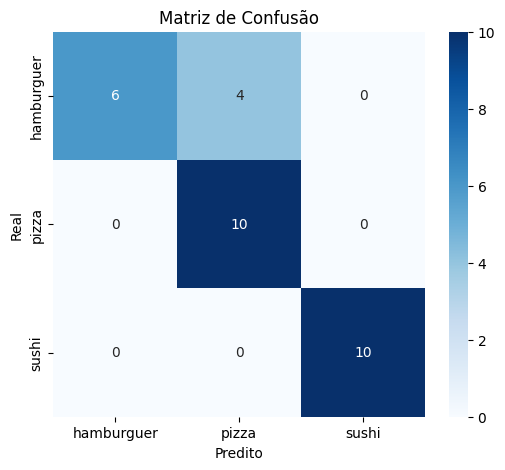


--- 2. Visualização do Dataset de Validação ---


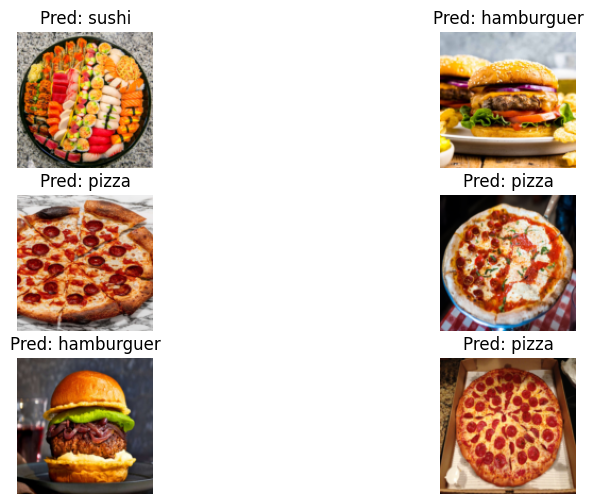


--- 3. Teste com Imagens da Internet (Outras Fontes) ---


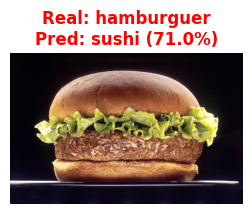

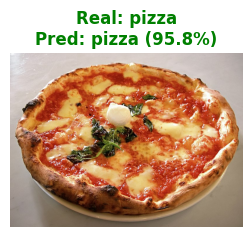

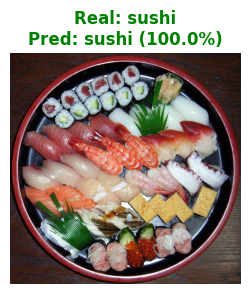

In [22]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
import requests
from PIL import Image
from io import BytesIO
from torchvision import transforms

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# 1. MÉTRICAS E MATRIZ DE CONFUSÃO
print(" 1. Avaliação Numérica")
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Cálculo da Acurácia
acc = accuracy_score(all_labels, all_preds)
print(f'Acurácia Global na Validação: {acc*100:.2f}%')

# Plot da Matriz de Confusão
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

# 2. VISUALIZAÇÃO
print("\n 2. Visualização do Dataset de Validação")
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure(figsize=(10, 6))

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'Pred: {class_names[preds[j]]}')

                # Desnormalizar para mostrar a imagem corretamente
                inp = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                inp = std * inp + mean
                inp = np.clip(inp, 0, 1)

                plt.imshow(inp)

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

visualize_model(model)
plt.show()

# 3. TESTE COM OUTRAS IMAGENS
print("\n 3. Teste com Imagens da Internet")

# URLs de imagens reais para teste
external_images = {
    "hamburguer": "https://upload.wikimedia.org/wikipedia/commons/thumb/4/47/Hamburger_%28black_bg%29.jpg/800px-Hamburger_%28black_bg%29.jpg",
    "pizza": "https://upload.wikimedia.org/wikipedia/commons/thumb/a/a3/Eq_it-na_pizza-margherita_sep2005_sml.jpg/800px-Eq_it-na_pizza-margherita_sep2005_sml.jpg",
    "sushi": "https://upload.wikimedia.org/wikipedia/commons/thumb/6/60/Sushi_platter.jpg/800px-Sushi_platter.jpg"
}

# Cabeçalho para "enganar" o servidor e parecer um navegador real
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

# Prepara transformação
preprocess = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

model.eval()

# Loop para baixar e testar cada imagem
for label_real, url in external_images.items():
    try:
        # Baixa a imagem COM HEADERS
        response = requests.get(url, headers=headers, stream=True)
        response.raise_for_status() # Garante que não deu erro 403/404

        img = Image.open(BytesIO(response.content)).convert('RGB')

        # Prepara para o modelo
        img_tensor = preprocess(img).unsqueeze(0).to(device)

        # Predição
        with torch.no_grad():
            outputs = model(img_tensor)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            conf, preds = torch.max(probs, 1)

        pred_label = class_names[preds.item()]
        confidence = conf.item() * 100

        color = 'green' if pred_label == label_real else 'red'

        # Mostra o resultado
        plt.figure(figsize=(3, 3))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Real: {label_real}\nPred: {pred_label} ({confidence:.1f}%)", color=color, fontweight='bold')
        plt.show()

    except Exception as e:
        print(f"Erro ao processar {label_real}: {e}")